### Load Modules

In [1]:
import os
import sys
from pathlib import Path

sys.path.append(str(Path(os.getcwd()).resolve()))

from tqdm import tqdm
from torchsummary import summary

import torch
import torch.optim as optim
import torch.nn as nn

from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR

import wandb
from torchsummary import summary

### Mount to Google drive

In [2]:
from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)
    print("Drive mounted successfully!")
else:
    print("Drive already mounted.")

Drive already mounted.


### Clone git and load modules

In [3]:
!git clone https://github.com/gimoonnam/vgg16_practice.git

fatal: destination path 'vgg16_practice' already exists and is not an empty directory.


In [4]:
repo_path = '/content/vgg16_practice'
if repo_path not in sys.path:
  sys.path.insert(0, repo_path)

from src.load_data import split_dataset
from models.vgg16 import VGG16
from src.data_classes import TrainingConfig

In [5]:
data_path = r'/content/drive/My Drive/Data for Colab Training'

# CIFAR10 dataset
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load from already downloaded dataset (set download=False)
# CIFAR-10 will be in data_path/cifar-10-batches-py/
dataset_train = datasets.CIFAR10(root=data_path, train=True, download=False, transform=transform)
dataset_test = datasets.CIFAR10(root=data_path, train=False, download=False, transform=transform)

print(f"Training samples: {len(dataset_train)}")
print(f"Test samples: {len(dataset_test)}")

Training samples: 50000
Test samples: 10000


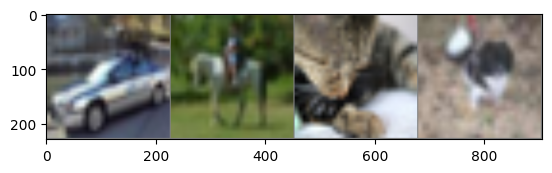

car   horse cat   dog  


In [6]:
import numpy as np
import matplotlib.pyplot as plt

import torchvision
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

trainloader = DataLoader(dataset_train, batch_size=4, shuffle=True)

# 학습용 이미지를 무작위로 가져오기
dataiter = iter(trainloader)
images, labels = next(dataiter)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


# 이미지 보여주기
imshow(torchvision.utils.make_grid(images))
# 정답(label) 출력
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))


In [7]:
train_dataset, val_dataset = split_dataset(dataset_train, train_ratio=0.8)

# Configuration for training
config = TrainingConfig(
    batch_size=64,
    num_epochs=20,
    num_train_samples=len(train_dataset),  # Set from your dataset
    lr_scheduler_epoch=5,
    save_path=r"/Users/gimoon/Documents/GitHub/vgg16_practice/checkpoints"
)
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training set size: 40000
Validation set size: 10000

Train batches: 625
Validation batches: 157


### Build VGG16 architecture

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VGG16(3, len(classes)).to(device)

print(device)

summary(model, (3, 224, 224))


cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            N_conv-6         [-1, 64, 112, 112]               0
            Conv2d-7        [-1, 128, 112, 112]          73,856
              ReLU-8        [-1, 128, 112, 112]               0
            Conv2d-9        [-1, 128, 112, 112]         147,584
             ReLU-10        [-1, 128, 112, 112]               0
        MaxPool2d-11          [-1, 128, 56, 56]               0
           N_conv-12          [-1, 128, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         295,168
             ReLU-14          [-1,

In [9]:
lr_scheduler_step_size = config.lr_scheduler_step_size()
print(lr_scheduler_step_size)

total_steps = config.total_steps()
print(total_steps)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
scheduler = StepLR(optimizer, step_size=config.lr_scheduler_step_size, gamma=0.5)

3125
12500


In [ ]:
from datetime import datetime
import pytz 

asia_tz = pytz.timezone("Asia/Seoul")
saved_time = datetime.now(asia_tz).strftime("%Y-%m-%d %H:%M:%S")
run_name = 'checkpoint-CIFAR10' + saved_time
print(run_name)

checkpoint-2026-02-16 13:49:59


In [ ]:
# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="gimoonnam",
    # Set the wandb project where this run will be logged.
    project="vgg16_practice",
    # Track hyperparameters and,
    name = run_name,

    config={
        "learning_rate": config.learning_rate,
        "architecture": "CNN",
        "dataset": "CIFAR-10",
        "epochs": config.num_epochs,
    },
)


for epoch in range(config.num_epochs):
    # ==================== TRAINING ====================
    model.train()
    epoch_train_loss = 0.0

    ProgressBar = tqdm(enumerate(train_loader), total=len(train_loader))

    for batch_idx, (inputs, labels) in ProgressBar:
        # Ensure labels are torch.long before moving to device for CrossEntropyLoss
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        # Update Progress bar (only training loss during training)
        ProgressBar.set_description(f'Epoch [{epoch+1}/{config.num_epochs}]')
        ProgressBar.set_postfix(TrainLoss=loss.item())

    # Average training loss for the epoch
    avg_train_loss = epoch_train_loss / len(train_loader)


    # ==================== VALIDATION (Once per epoch) ====================
    model.eval()
    val_loss = 0.0
    num_correct = 0
    num_samples = 0

    print(f"\nRunning validation for epoch {epoch+1}...")
    with torch.no_grad():
        for inputs_val, labels_val in tqdm(val_loader, desc="Validating"):
            inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)
            val_loss += loss_val.item()
            _, predictions = outputs_val.max(1)
            num_correct += (predictions == labels_val).sum()
            num_samples += predictions.size(0)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = (num_correct / num_samples).item() if num_samples > 0 else 0

    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")
    print(f"  Val Acc:    {avg_val_acc:.4f}")

    # # Update learning rate scheduler
    # scheduler.step()

    # Log metrics to wandb (once per epoch)
    run.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "val_accuracy": avg_val_acc
    })

run.finish()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: gimoonnam to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch [1/20]: 100%|██████████| 625/625 [02:06<00:00,  4.94it/s, TrainLoss=1.22]



Running validation for epoch 1...


Validating: 100%|██████████| 157/157 [00:18<00:00,  8.34it/s]



Epoch 1 Summary:
  Train Loss: 1.5359
  Val Loss:   1.3089
  Val Acc:    0.5307


...

Epoch [13/20]: 100%|██████████| 625/625 [02:06<00:00,  4.93it/s, TrainLoss=0.0666]



Running validation for epoch 13...


Validating: 100%|██████████| 157/157 [00:18<00:00,  8.38it/s]



Epoch 13 Summary:
  Train Loss: 0.0362
  Val Loss:   1.1703
  Val Acc:    0.7606


Epoch [14/20]:  33%|███▎      | 206/625 [00:41<01:23,  5.00it/s, TrainLoss=0.118]

In [ ]:
from vgg16_model import save_checkpoint, load_checkpoint


checkpoint_path = r'/content/drive/My Drive/checkpoints/cat-and-dog'
save_checkpoint(checkpoint_path, batch_size, num_epochs, model, optimizer, loss)

# pth_file_path = os.path.join(checkpoint_path, 'checkpoint-2026-02-12 09_10_08.pth')
# model, optimizer, epoch, loss = load_checkpoint(pth_file_path, model, optimizer)